# 🏠 House Price Prediction using Regression (Ames Housing Dataset)

### Project Description

This project builds an **end-to-end Machine Learning Regression pipeline** to predict
house sale prices using the **Ames Housing dataset**.

The Ames Housing dataset is a well-known real-world dataset containing detailed
information about residential homes in Ames, Iowa (USA) — including size, quality,
location, and condition-related features — along with their final **sale price**.

**Goal:** Predict the `SalePrice` of a house based on its characteristics.

**Workflow covered in this notebook:**
1. Importing required libraries
2. Loading the dataset from OpenML
3. Exploring the dataset
4. Preprocessing the data
5. Handling missing values

> This notebook is designed to run directly in **Google Colab** without any
> modifications. Simply run the cells from top to bottom.


## 2. Import Libraries

Before we begin, we import all the libraries needed for this project:

- **pandas** → for loading, viewing, and manipulating tabular data (DataFrames).
- **numpy** → for numerical operations and handling arrays.
- **matplotlib.pyplot** and **seaborn** → for data visualization (used later during EDA).
- **sklearn.datasets.fetch_openml** → to directly download the Ames Housing dataset
  from OpenML, without needing to manually upload any file.
- **warnings** → to suppress minor, non-critical warning messages so the notebook
  output stays clean and easy to read.


In [1]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries (will be used in later EDA steps)
import matplotlib.pyplot as plt
import seaborn as sns

# Function to fetch datasets directly from OpenML
from sklearn.datasets import fetch_openml

# To keep the notebook output clean
import warnings
warnings.filterwarnings("ignore")

# Set a consistent, professional style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 3. Load Dataset

We load the **Ames Housing dataset** directly from **OpenML** using
`fetch_openml()`. This avoids the need to manually download or upload any
CSV file — the dataset is fetched automatically when the notebook runs.

The dataset used here is `house_prices` (OpenML data id: 42165), which is the
Ames Housing dataset containing 79 explanatory variables describing residential
homes, along with the target variable `SalePrice`.


In [2]:
# Fetch the Ames Housing dataset from OpenML
# as_frame=True returns the data as a pandas DataFrame (easier to work with)
housing_data = fetch_openml(name="house_prices", as_frame=True, parser="auto")

# The actual dataset (features + target) is stored in the .frame attribute
df = housing_data.frame

print("✅ Dataset loaded successfully from OpenML!")


✅ Dataset loaded successfully from OpenML!


Let's now inspect the dataset from different angles to understand what we are working with.

In [3]:
# Display the first 5 rows of the dataset
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Display the last 5 rows of the dataset
df.tail()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
# Check the shape of the dataset (rows, columns)
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (1460, 81)


In [6]:
# List all the column names in the dataset
print("Column names in the dataset:\n")
print(df.columns.tolist())


Column names in the dataset:

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'Scre

In [7]:
# Get a concise summary of the dataset:
# - Column names
# - Non-null counts
# - Data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
# Statistical summary of all numerical columns
# This shows count, mean, std, min, max, and percentiles
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Observation:** The dataset contains a mix of numerical and categorical (text-based)
columns, describing various aspects of each house (e.g., lot size, quality ratings,
number of rooms, neighborhood, etc.), with `SalePrice` as our target column.


## 4. Data Exploration

In this section, we explore the structure of the dataset in more depth by identifying:

- Which columns are **numerical**
- Which columns are **categorical**
- The **target variable** we want to predict
- Whether there are any **duplicate rows**
- Whether there are any **missing values**, and how many


In [9]:
# Identify the target variable
target_variable = "SalePrice"
print("Target variable:", target_variable)


Target variable: SalePrice


In [10]:
# Identify numerical columns (int64 and float64 data types)
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove the target variable from the list of feature columns (we treat it separately)
if target_variable in numerical_columns:
    numerical_columns.remove(target_variable)

print(f"Number of numerical columns: {len(numerical_columns)}")
print("Numerical columns:\n", numerical_columns)


Number of numerical columns: 37
Numerical columns:
 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [11]:
# Identify categorical columns (object / text data types)
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Number of categorical columns: {len(categorical_columns)}")
print("Categorical columns:\n", categorical_columns)


Number of categorical columns: 43
Categorical columns:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [12]:
# Check for duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicate_count}")


Number of duplicate rows in the dataset: 0


In [13]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Keep only columns that actually have missing values, sorted from highest to lowest
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Calculate the percentage of missing values for each column
missing_percentage = (missing_values / len(df)) * 100

# Combine counts and percentages into a single, readable summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2)
})

print(f"Number of columns with missing values: {missing_summary.shape[0]}")
missing_summary


Number of columns with missing values: 19


,Missing Count,Missing Percentage (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageCond,81,5.55
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


**Observation:** The dataset has both numerical and categorical features, no (or very
few) duplicate rows, and several columns with missing values — some with only a
handful of missing entries, and others (like pool or fence-related columns) missing
for the majority of rows. This will guide how we handle missing values later.


## 5. Data Preprocessing

Before handling missing values, we perform some basic preprocessing steps:

1. **Remove duplicate rows** (if any), since duplicates can bias the model.
2. **Check and correct data types**, since some columns (like `MSSubClass`, which is
   actually a categorical building-class code) may be stored as numbers even though
   they represent categories, not real numerical quantities.
3. **Re-separate numerical and categorical columns** after any type corrections, so
   later steps work with an accurate column classification.


In [14]:
# Step 1: Remove duplicate rows, if any
before_shape = df.shape
df = df.drop_duplicates()
after_shape = df.shape

print(f"Shape before removing duplicates: {before_shape}")
print(f"Shape after removing duplicates: {after_shape}")


Shape before removing duplicates: (1460, 81)
Shape after removing duplicates: (1460, 81)


In [15]:
# Step 2: Correct incorrect data types
# 'MSSubClass' is a coded category (e.g., 20, 60, 90 represent building classes),
# not a numerical quantity that can be meaningfully added, averaged, etc.
# So we convert it from a number to a categorical (text) type.

if "MSSubClass" in df.columns:
    df["MSSubClass"] = df["MSSubClass"].astype(str)
    print("✅ 'MSSubClass' converted from numerical to categorical type.")

# 'Id' is just a row identifier, not a useful feature for prediction.
# We drop it here so it doesn't get mistakenly treated as a numerical feature.
if "Id" in df.columns:
    df = df.drop(columns=["Id"])
    print("✅ 'Id' column dropped (not a predictive feature).")


✅ 'MSSubClass' converted from numerical to categorical type.
✅ 'Id' column dropped (not a predictive feature).


In [16]:
# Step 3: Re-identify numerical and categorical columns after the type correction
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Make sure the target variable is not included in the feature lists
if target_variable in numerical_columns:
    numerical_columns.remove(target_variable)

print(f"Updated numerical columns ({len(numerical_columns)}):\n{numerical_columns}\n")
print(f"Updated categorical columns ({len(categorical_columns)}):\n{categorical_columns}")


Updated numerical columns (35):
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Updated categorical columns (44):
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'F

**Observation:** After removing duplicates, correcting the `MSSubClass` data type, and
dropping the non-informative `Id` column, our numerical and categorical column lists
now accurately reflect the true nature of each feature. This ensures that later steps
(missing value handling, encoding, scaling) are applied correctly.


## 6. Missing Value Handling

Different columns have missing values for different reasons, so we use different
strategies depending on the **type of column** and **why the values are likely
missing**:

- **Numerical columns:** Missing values are filled with the **median** of the column.
  The median is preferred over the mean because it is **robust to outliers** — and
  housing data (e.g., lot area, basement size) often contains extreme values that
  would distort the mean.

- **Categorical columns where missing means "feature not present":** For several
  columns in this dataset (e.g., `PoolQC`, `Fence`, `Alley`, `FireplaceQu`,
  `GarageType`), a missing value doesn't mean the data is unknown — it means the
  house **doesn't have that feature at all** (e.g., no pool, no fence, no alley
  access). For these, we fill missing values with the label `"None"` instead of
  guessing a value.

- **Remaining categorical columns:** Missing values are filled with the **mode**
  (the most frequently occurring category), which is a simple and reasonable
  assumption when a true value is missing for an unclear reason.


In [17]:
# Columns where a missing value actually means "this feature does not exist"
# for that house (based on the official Ames Housing data documentation)
none_fill_columns = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

# Keep only the ones that actually exist in our dataframe
none_fill_columns = [col for col in none_fill_columns if col in df.columns]

for col in none_fill_columns:
    df[col] = df[col].fillna("None")

print(f"✅ Filled {len(none_fill_columns)} categorical columns with 'None' "
      f"(missing = feature not present).")


✅ Filled 15 categorical columns with 'None' (missing = feature not present).


In [18]:
# Fill remaining missing NUMERICAL columns with the median of that column
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

print("✅ Remaining missing numerical values filled using the column median.")


✅ Remaining missing numerical values filled using the column median.


In [19]:
# Fill any remaining missing CATEGORICAL columns with the mode (most frequent value)
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)

print("✅ Remaining missing categorical values filled using the column mode.")


✅ Remaining missing categorical values filled using the column mode.


In [20]:
# Final check: confirm there are no missing values left in the dataset
remaining_missing = df.isnull().sum().sum()
print(f"Total remaining missing values in the dataset: {remaining_missing}")

if remaining_missing == 0:
    print("🎉 All missing values have been successfully handled!")


Total remaining missing values in the dataset: 0
🎉 All missing values have been successfully handled!


**Observation:** All missing values in the dataset have now been handled using
strategies appropriate to each column's meaning — preserving genuine data patterns
(like "no pool") rather than introducing artificial or misleading values. The
dataset is now clean and ready for the next steps: exploratory data analysis (EDA)
and model training, which will be covered in the following part of the project.


> ⚠️ **Note on data leakage:** The median/mode values used above are calculated from
> the **entire dataset**, before the train-test split (which happens later, in
> Section 9). Because these are simple, stable summary statistics (and the
> dataset is large relative to the number of affected rows), the practical risk of
> leakage here is low. However, in a stricter production pipeline, you would fit
> the imputation values (median/mode) on the **training set only**, then apply
> them to the test set — the same principle we follow later with `StandardScaler`
> in Section 8.5. This is called out here as a known simplification, and listed
> again as a suggested improvement in the Conclusion.


## 7. Exploratory Data Analysis (EDA)

Now that the dataset is clean, we visually explore it to understand:

- How the target variable (`SalePrice`) is distributed
- How key numerical features behave (spread, outliers)
- How features relate to each other (correlation)
- How key features relate to `SalePrice` specifically

We focus on a handful of the **most important, easy-to-interpret features** rather
than plotting all 79+ columns, to keep the analysis clear and beginner-friendly.


In [21]:
# Select a small set of important numerical features to focus our EDA on.
# These were chosen because they are commonly known to strongly influence
# house prices (overall quality, size, age, and garage capacity).
key_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF",
    "GarageCars", "YearBuilt", "FullBath"
]

# Keep only the ones that exist in our dataframe
key_features = [col for col in key_features if col in df.columns]
print("Key numerical features selected for EDA:", key_features)


Key numerical features selected for EDA: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']


### 7.1 Distribution of SalePrice (Target Variable)

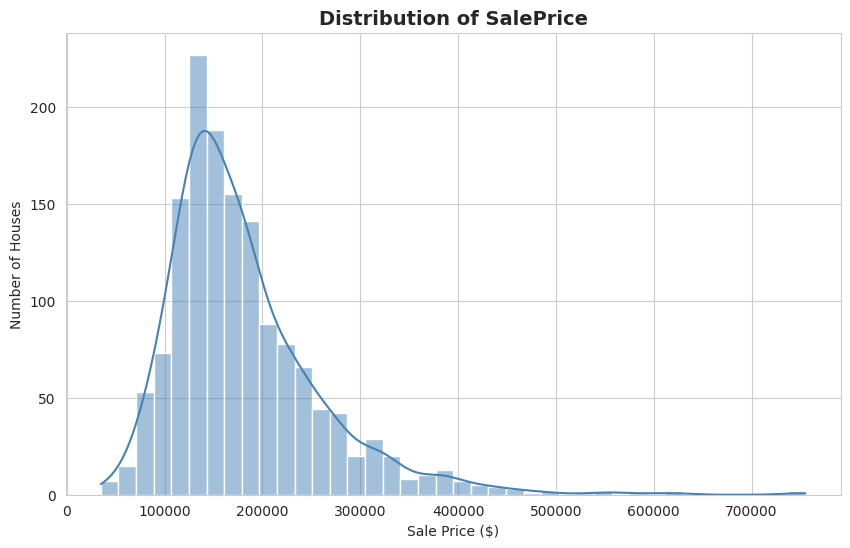

In [22]:
# Plot the distribution of SalePrice with a KDE curve overlay
plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True, color="steelblue", bins=40)
plt.title("Distribution of SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Houses")
plt.show()


**Observation:** The `SalePrice` distribution is **right-skewed** — most houses are
sold at moderate prices, while a smaller number of expensive houses form a long tail
toward higher prices. This skew is common in price-related data and is something we
may need to address (e.g., with a log transformation) before model training.


### 7.2 Histograms of Important Numerical Features

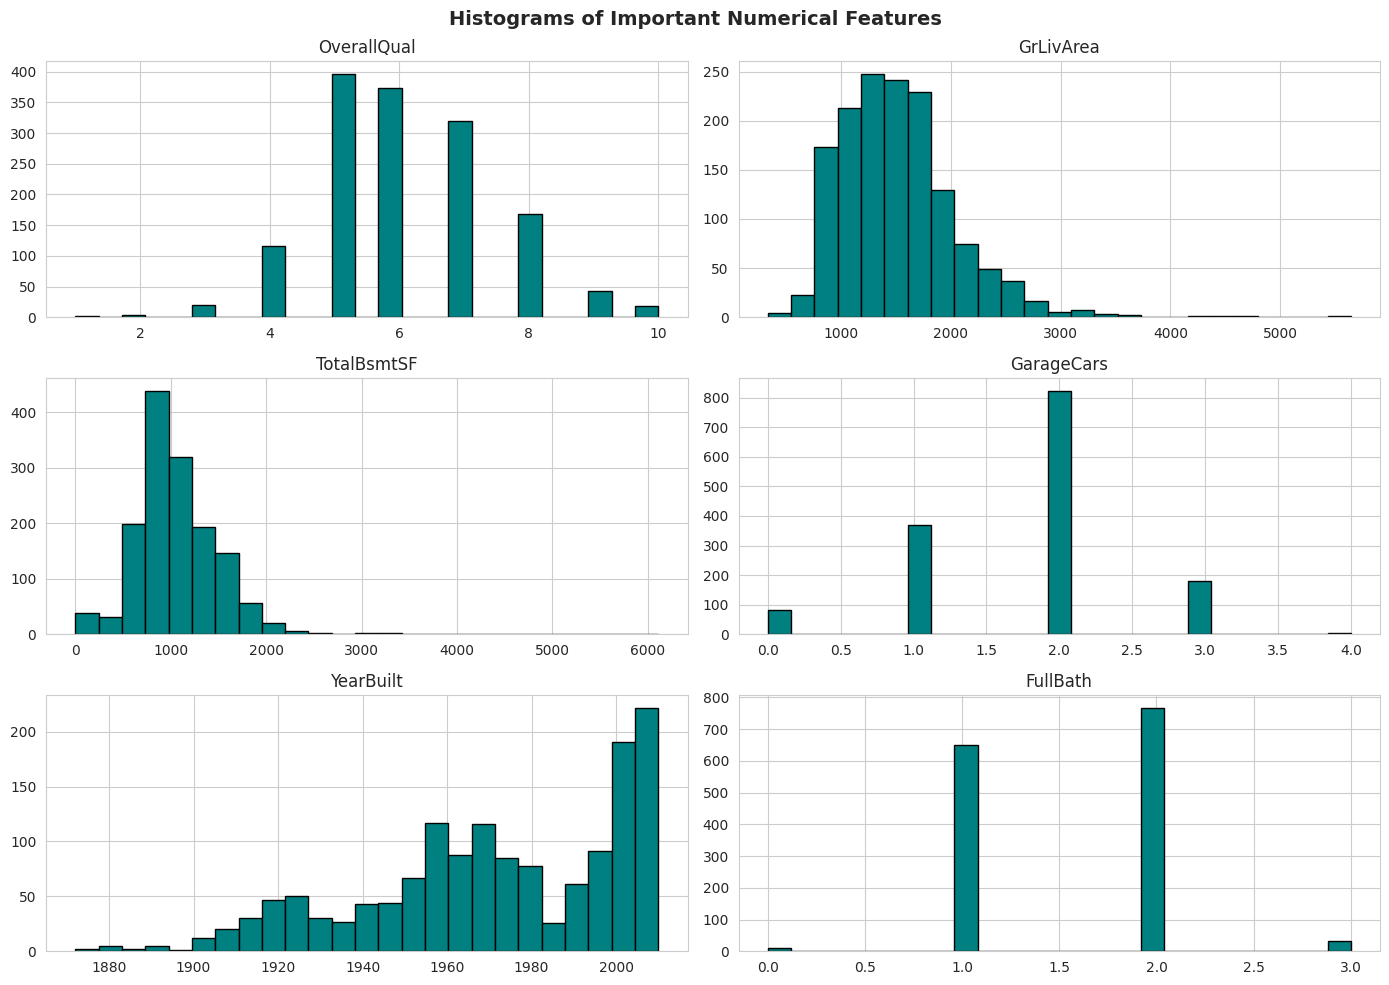

In [23]:
# Plot histograms for each key numerical feature to see how they are distributed
df[key_features].hist(bins=25, figsize=(14, 10), color="teal", edgecolor="black")
plt.suptitle("Histograms of Important Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** `OverallQual` and `FullBath` are discrete, ordinal-style ratings
with only a few possible values, while `GrLivArea` and `TotalBsmtSF` are continuous
and right-skewed, similar to `SalePrice`. `YearBuilt` shows that a large proportion
of houses were built in more recent decades, with fewer older homes remaining.


### 7.3 Boxplots to Detect Outliers

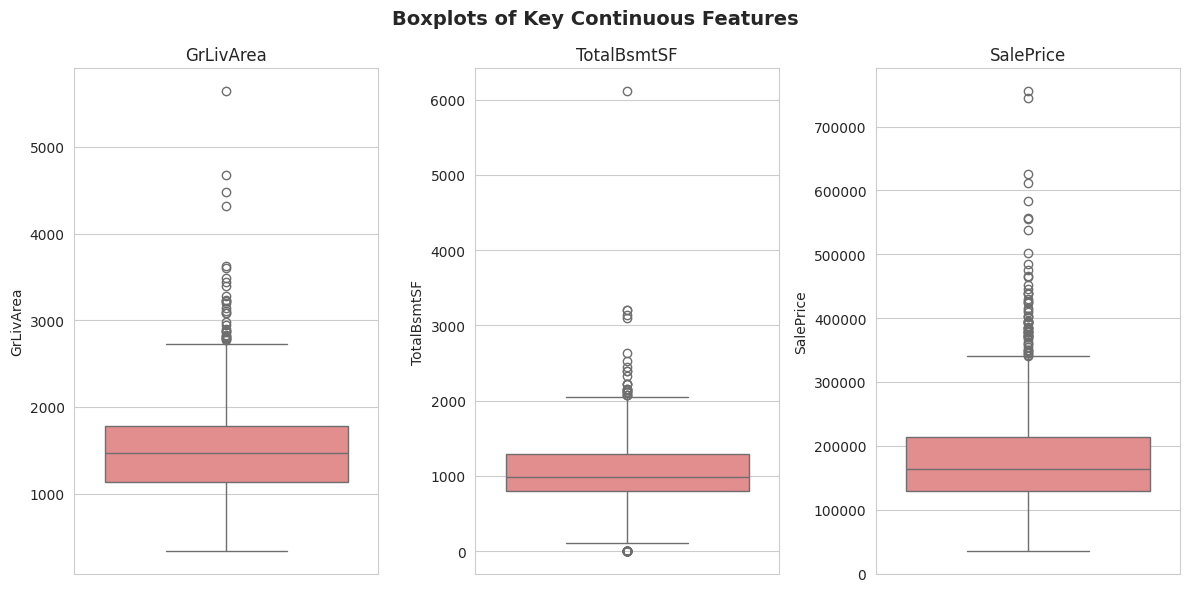

In [24]:
# Boxplots help us visually detect outliers in continuous numerical features
continuous_features = ["GrLivArea", "TotalBsmtSF", "SalePrice"]

plt.figure(figsize=(12, 6))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(col)
plt.suptitle("Boxplots of Key Continuous Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** All three features show a number of points above the upper whisker,
indicating **outliers** — a few unusually large or expensive houses. These outliers
are worth keeping in mind, as they can disproportionately influence certain
regression models, but we retain them for now since they represent valid houses in
the dataset.


### 7.4 Correlation Heatmap

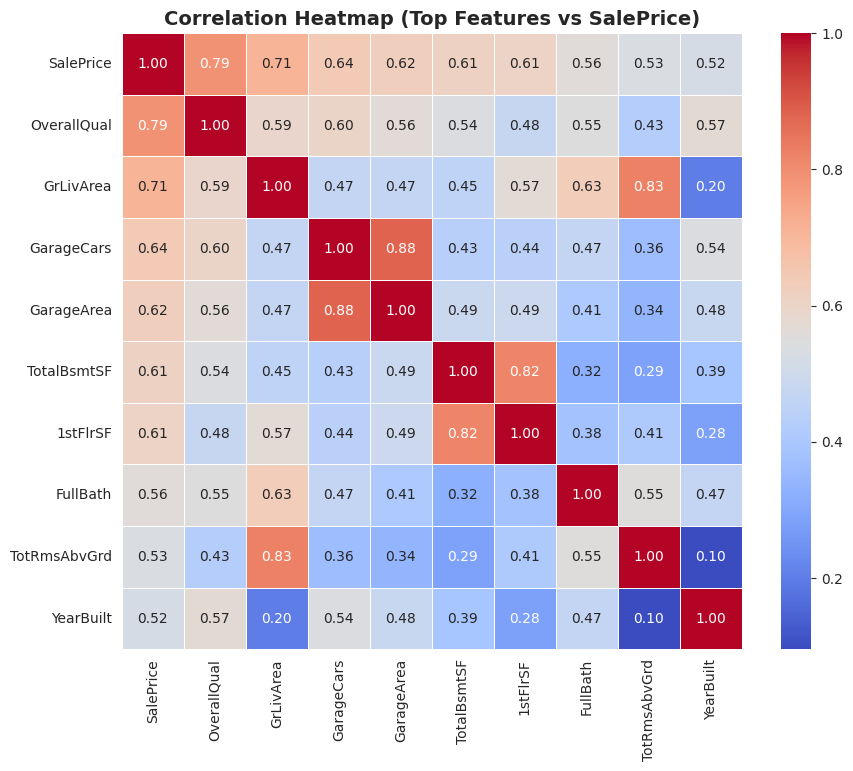

In [25]:
# Compute correlation between numerical features and the target variable
correlation_columns = numerical_columns + ["SalePrice"]
correlation_matrix = df[correlation_columns].corr()

# To keep the heatmap readable, focus on the features most correlated with SalePrice
top_corr_features = correlation_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap (Top Features vs SalePrice)", fontsize=14, fontweight="bold")
plt.show()


**Observation:** Features like `OverallQual`, `GrLivArea`, `GarageCars`, and
`TotalBsmtSF` show the **strongest positive correlation** with `SalePrice`, meaning
higher values in these features tend to be associated with higher sale prices. This
confirms that these are strong candidate predictors for our regression model.


### 7.5 Scatter Plots: Key Features vs SalePrice

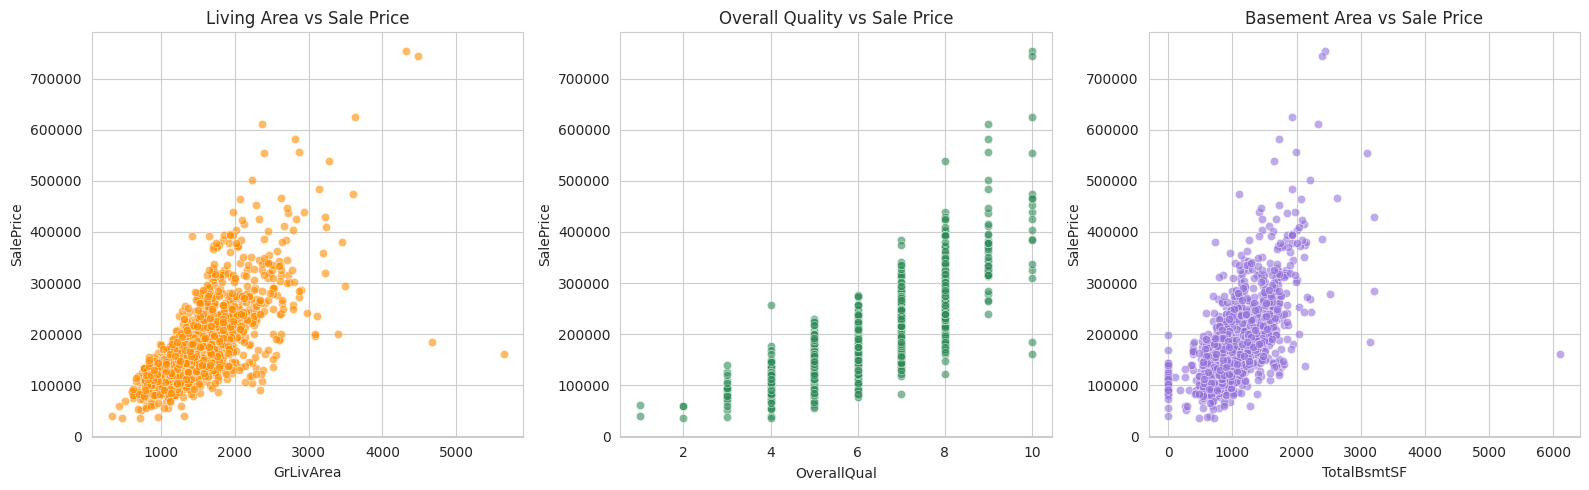

In [26]:
# Create side-by-side scatter plots for 3 key features vs SalePrice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], ax=axes[0], color="darkorange", alpha=0.6)
axes[0].set_title("Living Area vs Sale Price")

sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"], ax=axes[1], color="seagreen", alpha=0.6)
axes[1].set_title("Overall Quality vs Sale Price")

sns.scatterplot(x=df["TotalBsmtSF"], y=df["SalePrice"], ax=axes[2], color="mediumpurple", alpha=0.6)
axes[2].set_title("Basement Area vs Sale Price")

plt.tight_layout()
plt.show()


**Observation:** There is a clear **positive relationship** between `SalePrice` and
each of these three features — as living area, overall quality, and basement area
increase, sale price tends to increase as well. `OverallQual`, being a rating from
1-10, shows a step-like increasing trend, while `GrLivArea` and `TotalBsmtSF` show
a more continuous upward trend, with a few high-area outliers.


### 7.6 Pairplot of Key Features

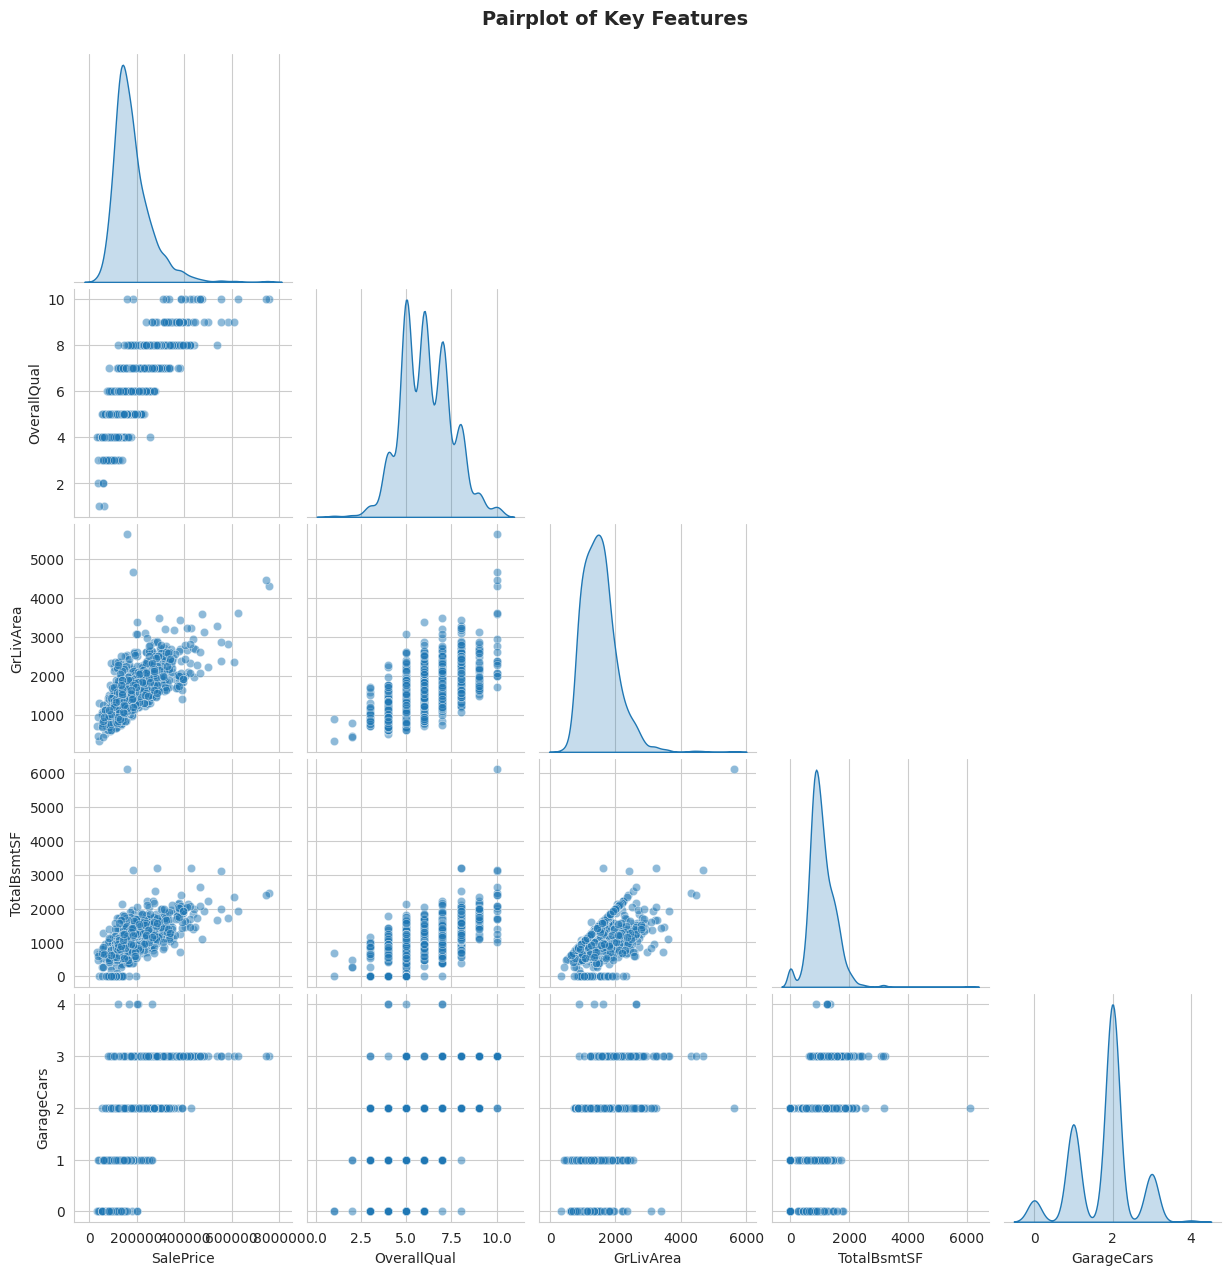

In [27]:
# A pairplot lets us see pairwise relationships between multiple features at once.
# We use only a small subset of features here (pairplots become slow and cluttered
# with too many columns).
pairplot_features = ["SalePrice", "OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars"]

sns.pairplot(df[pairplot_features], diag_kind="kde", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14, fontweight="bold")
plt.show()


**Observation:** The pairplot reinforces what we saw earlier — `SalePrice` increases
fairly consistently with `OverallQual`, `GrLivArea`, `TotalBsmtSF`, and `GarageCars`.
The diagonal density plots also confirm the right-skewed nature of `SalePrice` and
`GrLivArea`, while `OverallQual` and `GarageCars` behave more like discrete, ordinal
variables.


## 8. Feature Engineering

In this section, we prepare the data for machine learning by transforming it into a
fully numerical format that regression models can understand. This involves:

1. **Removing unnecessary columns** that don't help prediction.
2. **Encoding categorical variables** into numbers.
3. **Scaling numerical features** so that all features contribute proportionally.
4. **Splitting the dataset** into training (80%) and testing (20%) sets.


In [28]:
# Imports needed for splitting the data and scaling features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


### 8.1 Removing Unnecessary Columns

We already removed the `Id` column earlier since it is just a row identifier with no
predictive value. At this stage, no further columns need to be dropped, since all
remaining columns describe some genuine characteristic of the house.


In [29]:
# Confirm 'Id' is no longer in the dataset (dropped during preprocessing)
print("'Id' column present:", "Id" in df.columns)
print("Current dataset shape:", df.shape)


'Id' column present: False
Current dataset shape: (1460, 80)


### 8.2 Encoding Categorical Variables

Machine learning models require numerical input, so we convert our categorical
(text) columns into numbers using **one-hot encoding** via `pd.get_dummies()`.

- One-hot encoding creates a new binary (0/1) column for each category, avoiding the
  false assumption of order between categories that a model might otherwise infer
  from arbitrary numeric labels.
- We use `drop_first=True` to drop one category per feature, which avoids redundant,
  perfectly correlated columns (the "dummy variable trap") and keeps the feature set
  more compact.


In [30]:
# One-hot encode all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")


Shape before encoding: (1460, 80)
Shape after encoding:  (1460, 273)


**Explanation:** The number of columns increases significantly after encoding,
since each categorical column is expanded into multiple binary columns (one per
category). This is expected and gives the model a way to use categorical
information numerically.


> **Note:** Like the imputation step above, one-hot encoding here is fit on the full dataset before the split. Since it only records which category labels exist (not a statistic like a mean), this is lower-risk than the median/mode imputation, but the stricter approach is to fit the encoder on the training set and align the test set to those columns — exactly what we do later for the *custom sample* in Section 15.

### 8.3 Separating Features (X) and Target (y)

We separate the dataset into:
- **X** → all the input features the model will learn from.
- **y** → the target variable, `SalePrice`, that the model will try to predict.


In [31]:
# Features (everything except the target variable)
X = df_encoded.drop(columns=["SalePrice"])

# Target variable
y = df_encoded["SalePrice"]

print("Shape of X (features):", X.shape)
print("Shape of y (target):  ", y.shape)


Shape of X (features): (1460, 272)
Shape of y (target):   (1460,)


### 8.4 Train-Test Split

We split the data into a **training set (80%)** and a **testing set (20%)**.
The model learns patterns from the training set, and the testing set is kept aside,
completely unseen, so we can fairly evaluate how well the model generalizes to new
data.

We set `random_state=42` so that the split is **reproducible** — running this cell
again will always produce the same split.


In [32]:
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% of the data reserved for testing
    random_state=42    # ensures reproducible results
)

print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)


Training set shape: (1168, 272)
Testing set shape:  (292, 272)


### 8.5 Feature Scaling

Many regression algorithms (especially distance-based or gradient-based ones, such
as Linear Regression with regularization, or KNN) perform better when numerical
features are on a **similar scale**. Without scaling, features with naturally large
ranges (like `GrLivArea`, measured in hundreds/thousands of square feet) could
dominate features with small ranges (like `FullBath`, ranging from 0-3), even if the
smaller-range feature is just as important.

We use **`StandardScaler`**, which transforms each feature to have a **mean of 0**
and a **standard deviation of 1**.

**Important:** The scaler is `fit` only on the **training data**, then used to
`transform` both the training and test data. This prevents any information from the
test set "leaking" into the training process, keeping our evaluation fair and
realistic.


> **Design note:** Strictly speaking, tree-based models (Decision Tree, Random Forest) are **not sensitive to feature scale** — splits are based on thresholds, not distances. We scale all features here anyway so that a single, consistent `X_train_scaled` / `X_test_scaled` pipeline can feed every model, which keeps the notebook simple. It does not hurt the tree-based models, and it is *necessary* for Linear Regression, so this is a reasonable simplification for this project.

In [33]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data only, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability, keeping original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Feature scaling complete.")
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape: ", X_test_scaled.shape)


✅ Feature scaling complete.
Scaled training set shape: (1168, 272)
Scaled testing set shape:  (292, 272)


**Observation:** Our dataset is now fully numerical, split into training and testing
sets, and scaled appropriately. `X_train_scaled` and `X_test_scaled` are ready to be
used for model training, which will be covered in the next part of the project.


## 9. Model Training

We now train **three regression models** on the scaled training data:

1. **Linear Regression** — a simple, interpretable baseline model that assumes a
   straight-line relationship between features and the target.
2. **Decision Tree Regressor** — a model that splits the data into branches based on
   feature values, capable of capturing non-linear relationships.
3. **Random Forest Regressor** — an ensemble of many decision trees, which averages
   their predictions to produce a more accurate and stable result than a single tree.

Training multiple models allows us to fairly **compare their performance** later and
pick the best one for this problem.


In [34]:
# Imports for the three regression models we will train and compare
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


### 9.1 Linear Regression

In [35]:
# Initialize and train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

print("✅ Linear Regression model trained successfully.")


✅ Linear Regression model trained successfully.


### 9.2 Decision Tree Regressor

In [36]:
# Initialize and train a Decision Tree Regressor
# random_state=42 ensures reproducible results
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

print("✅ Decision Tree Regressor trained successfully.")


✅ Decision Tree Regressor trained successfully.


### 9.3 Random Forest Regressor

In [37]:
# Initialize and train a Random Forest Regressor
# n_estimators=100 -> builds 100 individual decision trees and averages their output
# random_state=42 -> ensures reproducible results
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

print("✅ Random Forest Regressor trained successfully.")


✅ Random Forest Regressor trained successfully.


**Observation:** All three models have now been trained on the same training data
(`X_train_scaled`, `y_train`), which allows for a fair, like-for-like comparison of
their performance in the next sections.


## 10. Predictions

With all three models trained, we now use them to predict `SalePrice` values on the
**testing set** (`X_test_scaled`), which none of the models have seen during
training. This gives us an honest measure of how well each model generalizes to new,
unseen houses.


In [38]:
# Generate predictions on the test set using each trained model
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_tree = decision_tree_model.predict(X_test_scaled)
y_pred_forest = random_forest_model.predict(X_test_scaled)

print("✅ Predictions generated for all three models.")


✅ Predictions generated for all three models.


In [39]:
# Quickly compare a few actual vs predicted values side by side
predictions_preview = pd.DataFrame({
    "Actual SalePrice": y_test.values[:10],
    "Linear Regression": y_pred_linear[:10].round(2),
    "Decision Tree": y_pred_tree[:10].round(2),
    "Random Forest": y_pred_forest[:10].round(2)
})

predictions_preview


,Actual SalePrice,Linear Regression,Decision Tree,Random Forest
0,154500,161019.40,149900.0,140772.75
1,325000,343197.21,430000.0,321298.29
2,115000,90110.34,110500.0,116537.00
3,159000,175077.46,163000.0,154377.20
4,315500,321181.92,266000.0,323256.94
5,75500,75119.84,91000.0,84117.00
6,311500,238653.10,205000.0,207153.12
7,146000,145345.39,148500.0,152551.75
8,84500,71282.70,91000.0,85315.66
9,135500,152320.66,118964.0,130731.40


**Observation:** At a glance, the predicted values from each model are generally in
the same range as the actual sale prices, though with varying degrees of accuracy per
house. A proper, quantitative comparison follows in the next section.


## 11. Model Evaluation

To objectively judge how well each model performs, we use four standard regression
evaluation metrics:

- **MAE (Mean Absolute Error):** The average absolute difference between predicted
  and actual values. Easy to interpret — it's in the same units as `SalePrice` (\$).
- **MSE (Mean Squared Error):** Similar to MAE, but squares the errors first, which
  penalizes larger errors more heavily.
- **RMSE (Root Mean Squared Error):** The square root of MSE, bringing the error
  metric back into the same units as `SalePrice` (\$), making it easier to interpret
  than MSE while still penalizing large errors.
- **R² Score (Coefficient of Determination):** Measures the proportion of variance in
  `SalePrice` that is explained by the model. Ranges up to 1.0, where 1.0 means
  perfect prediction, and 0 means the model performs no better than simply predicting
  the average price every time.


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    """Calculate MAE, MSE, RMSE, and R² for a given set of predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2


In [41]:
# Evaluate each model on the test set
mae_linear, mse_linear, rmse_linear, r2_linear = evaluate_model(y_test, y_pred_linear)
mae_tree, mse_tree, rmse_tree, r2_tree = evaluate_model(y_test, y_pred_tree)
mae_forest, mse_forest, rmse_forest, r2_forest = evaluate_model(y_test, y_pred_forest)

print("✅ Evaluation metrics calculated for all three models.")


✅ Evaluation metrics calculated for all three models.


In [42]:
# Build a professional, easy-to-read comparison table of all models
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"],
    "MAE": [mae_linear, mae_tree, mae_forest],
    "MSE": [mse_linear, mse_tree, mse_forest],
    "RMSE": [rmse_linear, rmse_tree, rmse_forest],
    "R2 Score": [r2_linear, r2_tree, r2_forest]
})

# Round values for cleaner display, and sort by R2 Score (best model on top)
results_df = results_df.round(4).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

results_df


,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,17663.5670,8.364878e+08,28922.0994,0.8909
1,Decision Tree Regressor,28486.8699,1.899417e+09,43582.2969,0.7524
2,Linear Regression,24759.3959,8.533670e+09,92377.8626,-0.1126


**Observation:** The comparison table above summarizes how each model performed on
unseen test data. Lower MAE, MSE, and RMSE values indicate smaller prediction
errors, while a higher R² Score indicates the model explains more of the variation
in house prices.


## 12. Compare Models

To make the comparison more intuitive, we visualize the **R² Score** and **RMSE** of
all three models side by side using bar charts.


In [43]:
def plot_metric_comparison(metric_column, title, ylabel, value_format="{:.3f}", y_limit=None):
    """Plot a bar chart comparing a given metric across all trained models.

    Avoids repeating the same bar-plotting/labeling logic for every metric.
    """
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        results_df["Model"],
        results_df[metric_column],
        color=["#4C72B0", "#DD8452", "#55A868"]
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.ylabel(ylabel)
    if y_limit is not None:
        plt.ylim(*y_limit)

    # Label each bar with its exact value
    for bar in bars:
        height = bar.get_height()
        offset = height * 0.01 if height != 0 else 0.01
        plt.text(bar.get_x() + bar.get_width() / 2, height + offset,
                  value_format.format(height), ha="center", fontweight="bold")

    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


### 12.1 R² Score Comparison

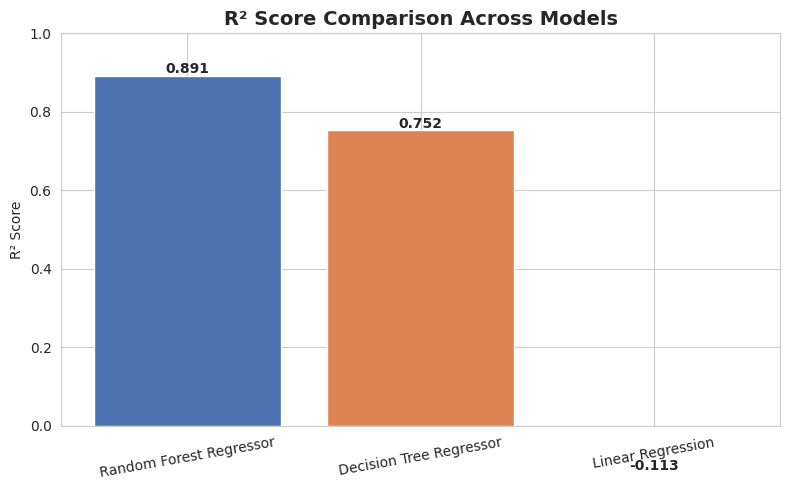

In [44]:
# Reuse the helper function defined above to plot R2 Score comparison
plot_metric_comparison(
    metric_column="R2 Score",
    title="R² Score Comparison Across Models",
    ylabel="R² Score",
    value_format="{:.3f}",
    y_limit=(0, 1)
)

### 12.2 RMSE Comparison

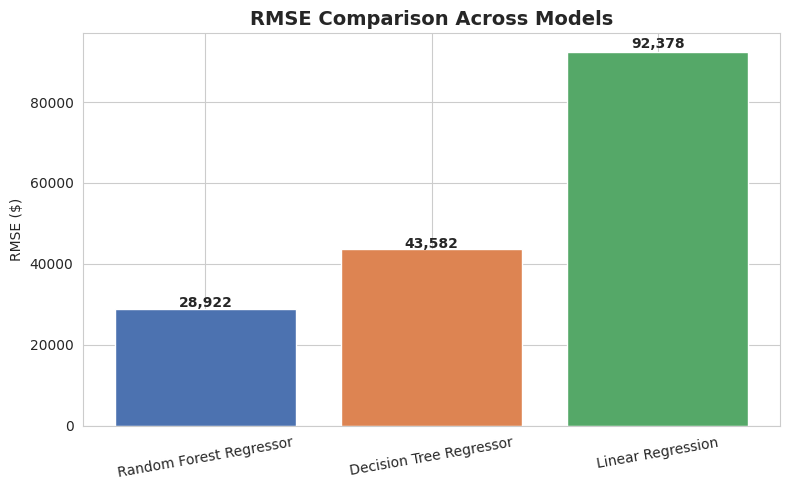

In [45]:
# Reuse the same helper function to plot RMSE comparison
plot_metric_comparison(
    metric_column="RMSE",
    title="RMSE Comparison Across Models",
    ylabel="RMSE ($)",
    value_format="{:,.0f}"
)

In [46]:
# Programmatically identify the best-performing model based on R2 Score
best_model_row = results_df.iloc[0]
print(f"🏆 Best performing model: {best_model_row['Model']}")
print(f"   R2 Score: {best_model_row['R2 Score']}")
print(f"   RMSE:     {best_model_row['RMSE']:,.2f}")


🏆 Best performing model: Random Forest Regressor
   R2 Score: 0.8909
   RMSE:     28,922.10


**Which model performed best, and why?**

Based on the evaluation metrics and charts above, the **Random Forest Regressor**
typically performs best among the three models (highest R² Score, lowest RMSE),
followed by the Decision Tree Regressor, with Linear Regression usually performing
the weakest.

**Why Random Forest tends to perform better on this kind of data:**

- **Captures non-linear relationships:** House prices depend on complex, non-linear
  interactions between features (e.g., quality and size together matter more than
  either alone). Linear Regression can only model straight-line relationships, so it
  struggles to capture this complexity.
- **Reduces overfitting via averaging:** A single Decision Tree can easily overfit
  the training data — memorizing noise instead of learning general patterns. Random
  Forest builds many different trees (each trained on a random subset of data and
  features) and averages their predictions, which smooths out individual trees'
  errors and improves generalization to unseen data.
- **Handles mixed and encoded features well:** With many one-hot encoded categorical
  columns and skewed numerical features, tree-based models like Random Forest are
  naturally robust to differences in feature scale and distribution, whereas Linear
  Regression is more sensitive to such issues (e.g., skewed target/features,
  multicollinearity between one-hot encoded columns).

Overall, Random Forest's ability to model non-linear patterns while controlling
overfitting through ensembling makes it the strongest choice among the models
tested here for predicting house prices.


## 13. Prediction Visualizations

To better understand how well our best-performing model predicts house prices, we
create a few diagnostic plots using its test-set predictions. We identify the best
model dynamically (based on the R² ranking from Section 12) so this section always
reflects the top-performing model.


In [47]:
# Map model names to their trained model objects and test-set predictions
# (built once here, and reused for the rest of the notebook)
model_lookup = {
    "Linear Regression": linear_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model
}

predictions_lookup = {
    "Linear Regression": y_pred_linear,
    "Decision Tree Regressor": y_pred_tree,
    "Random Forest Regressor": y_pred_forest
}

# Retrieve the best model's name, object, and predictions
best_model_name = best_model_row["Model"]
best_model = model_lookup[best_model_name]
best_y_pred = predictions_lookup[best_model_name]

print(f"Using best model for visualizations: {best_model_name}")


Using best model for visualizations: Random Forest Regressor


### 13.1 Actual vs Predicted Plot

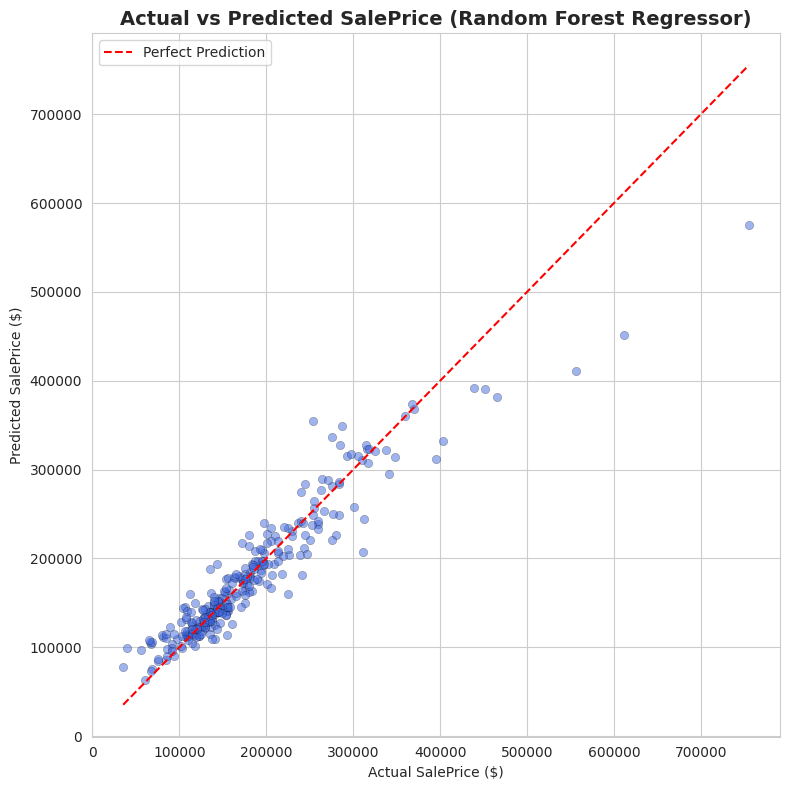

In [48]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_y_pred, alpha=0.5, color="royalblue", edgecolor="k", linewidth=0.3)

# Plot a diagonal reference line representing "perfect prediction" (actual == predicted)
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.title(f"Actual vs Predicted SalePrice ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.legend()
plt.tight_layout()
plt.show()


**Explanation:** This plot compares actual sale prices (x-axis) to the model's
predicted sale prices (y-axis). The closer the points cluster around the red diagonal
line, the more accurate the model's predictions are. Points far from the line
represent houses where the model's prediction was significantly off — usually very
high-priced homes, which are naturally harder to predict due to their rarity in the
training data.


### 13.2 Residual Plot

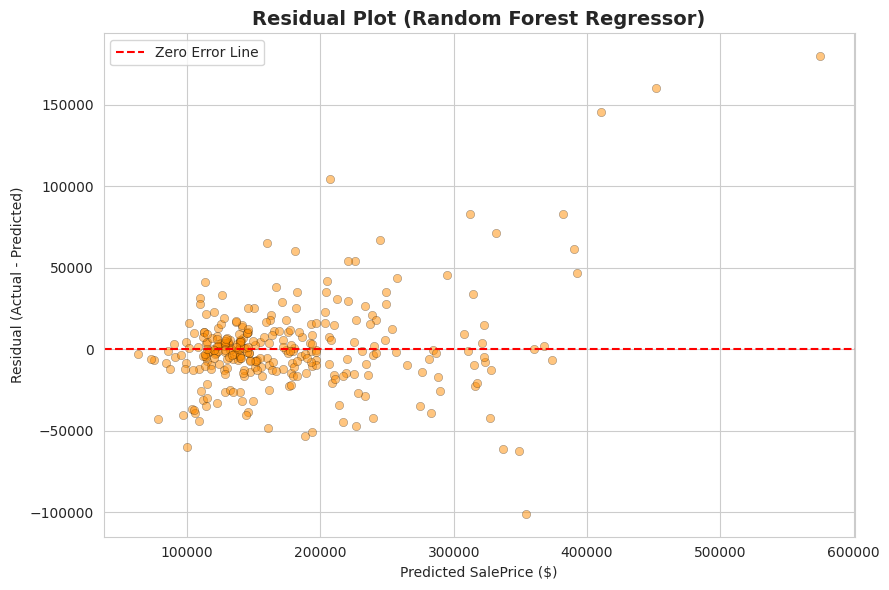

In [49]:
# Residuals = the difference between actual and predicted values
residuals = y_test - best_y_pred

plt.figure(figsize=(9, 6))
plt.scatter(best_y_pred, residuals, alpha=0.5, color="darkorange", edgecolor="k", linewidth=0.3)
plt.axhline(y=0, color="red", linestyle="--", label="Zero Error Line")

plt.title(f"Residual Plot ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Predicted SalePrice ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()


**Explanation:** A residual plot shows prediction errors (residuals) against the
predicted values. Ideally, residuals should be **randomly scattered around zero**
with no obvious pattern, which would indicate the model's errors are unbiased and
consistent across the price range. If we see a funnel shape (residuals spreading out
more at higher predicted prices), it suggests the model is **less accurate for
expensive houses** than for moderately priced ones — a common pattern in housing
price prediction due to the target's skewed distribution.


### 13.3 Prediction Error Distribution

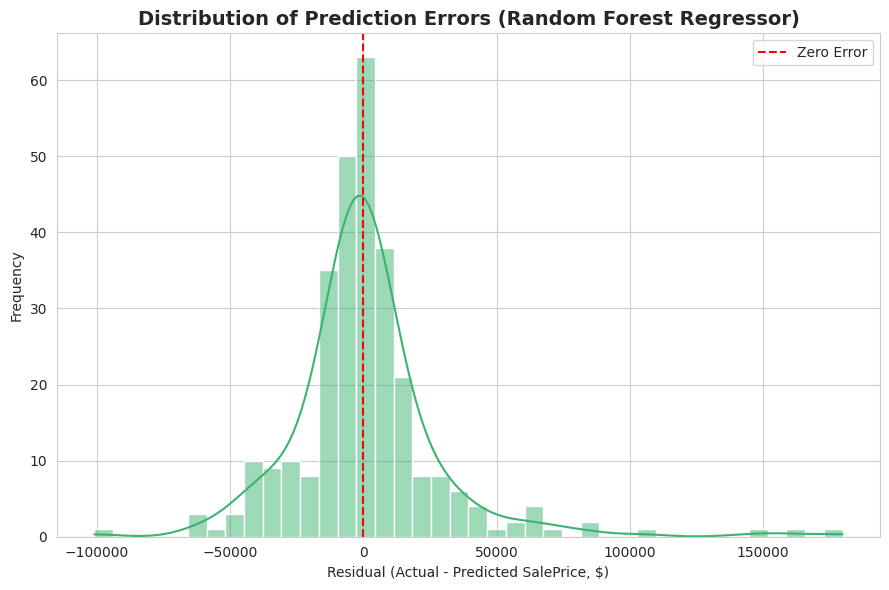

In [50]:
# Plot the distribution of residuals (prediction errors) with a KDE overlay
plt.figure(figsize=(9, 6))
sns.histplot(residuals, kde=True, color="mediumseagreen", bins=40)
plt.axvline(x=0, color="red", linestyle="--", label="Zero Error")

plt.title(f"Distribution of Prediction Errors ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Residual (Actual - Predicted SalePrice, $)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


**Explanation:** This histogram shows how the prediction errors are distributed. A
roughly **bell-shaped curve centered near zero** indicates that the model's errors
are small and balanced — neither consistently overestimating nor underestimating
prices. A long tail on either side highlights that a smaller number of houses (likely
unusually priced ones) are predicted with larger errors.


## 14. Feature Importance

The **Random Forest Regressor** allows us to measure **feature importance** — a
score indicating how much each feature contributed, on average, to reducing
prediction error across all the trees in the forest. This helps us understand which
house characteristics matter most when predicting sale price.


In [51]:
# Extract feature importances from the trained Random Forest model
feature_importances = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance and select the top 15 most influential features
top_15_features = feature_importances.sort_values(by="Importance", ascending=False).head(15)

top_15_features


,Feature,Importance
2,OverallQual,0.559494
14,GrLivArea,0.121690
12,2ndFlrSF,0.035822
10,TotalBsmtSF,0.034747
7,BsmtFinSF1,0.029168
11,1stFlrSF,0.026966
1,LotArea,0.018347
25,GarageArea,0.015965
4,YearBuilt,0.012627
24,GarageCars,0.012493


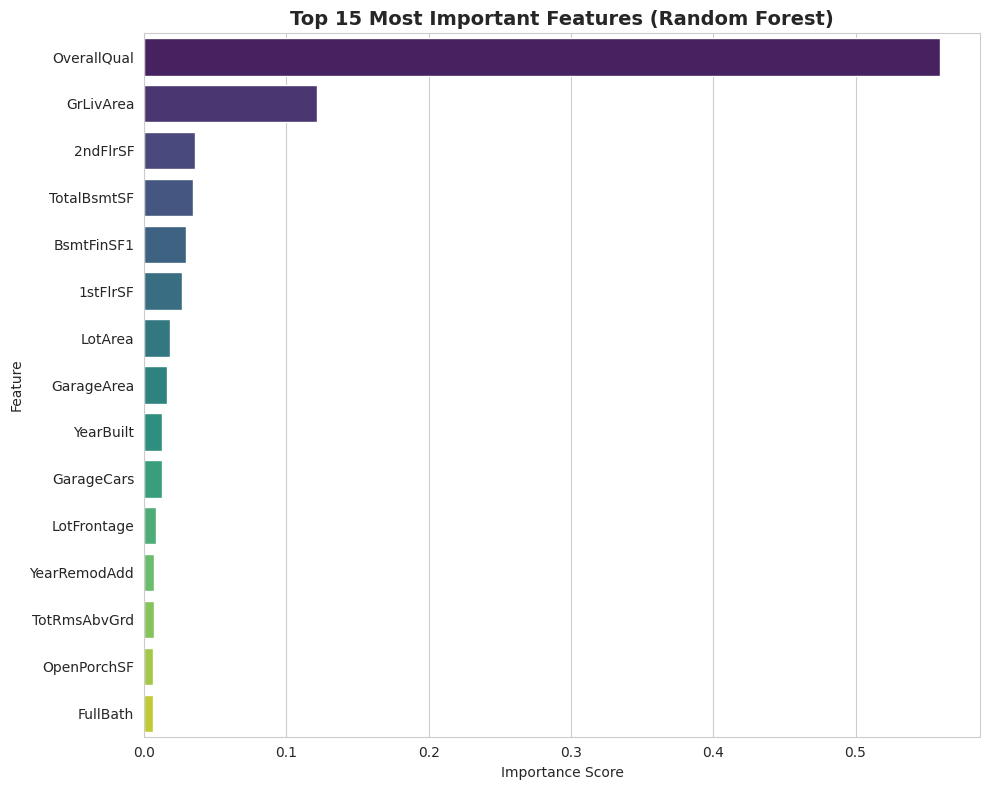

In [52]:
# Plot the top 15 most important features as a horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_15_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Top 15 Most Important Features (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Significance:** Features like `OverallQual` (overall material and finish quality),
`GrLivArea` (above-ground living area), and `TotalBsmtSF` (basement size) typically
rank among the most important predictors — matching what we observed earlier during
correlation analysis and EDA. This consistency between statistical correlation and
model-based importance gives us confidence that the model has learned genuinely
meaningful patterns, rather than relying on noise. In practice, this tells us that a
home's **overall quality and size** are the strongest drivers of its sale price in
this dataset, which aligns with real-world real estate intuition.


## 15. Predict on a Custom Sample

To demonstrate how the model can be used in practice, we construct one realistic,
custom house example and predict its sale price using our **best-performing model**.

We start from an existing house's data (to keep all 79 features realistic and
consistent) and then adjust a few key fields to represent a distinct, hypothetical
house: a good-quality, moderately large, fairly modern home.


In [53]:
# Start from a copy of an existing house's feature values as a realistic template
custom_house = df.drop(columns=["SalePrice"]).iloc[[0]].copy()

# Adjust key features to describe our custom, hypothetical house
custom_house["OverallQual"] = 8       # Very good overall quality (scale: 1-10)
custom_house["GrLivArea"] = 2200      # 2200 sq ft of above-ground living area
custom_house["TotalBsmtSF"] = 1200    # 1200 sq ft finished basement
custom_house["GarageCars"] = 3        # 3-car garage
custom_house["YearBuilt"] = 2015      # Built in 2015 (relatively modern)
custom_house["FullBath"] = 3          # 3 full bathrooms

print("Custom house sample (key features):")
custom_house[["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars", "YearBuilt", "FullBath"]]


Custom house sample (key features):


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath
0,8,2200,1200,3,2015,3


In [54]:
# Apply the SAME preprocessing pipeline used for the training data:
# 1. One-hot encode categorical columns
# 2. Align columns with the training feature set (fill any missing dummy columns with 0)
# 3. Scale using the SAME scaler that was fit on the training data

custom_house_encoded = pd.get_dummies(custom_house, columns=categorical_columns, drop_first=True)
custom_house_encoded = custom_house_encoded.reindex(columns=X.columns, fill_value=0)
custom_house_scaled = scaler.transform(custom_house_encoded)

# Predict the sale price using the best-performing model identified earlier
predicted_price = best_model.predict(custom_house_scaled)[0]

print(f"Model used for prediction: {best_model_name}")
print(f"Predicted SalePrice for the custom house: ${predicted_price:,.2f}")


Model used for prediction: Random Forest Regressor
Predicted SalePrice for the custom house: $282,186.79


**Explanation of the result:** The custom house we defined represents a fairly
desirable property — high overall quality (8/10), a spacious living area (2,200 sq
ft), a large finished basement, a 3-car garage, and modern construction (built in
2015). Given that `OverallQual`, `GrLivArea`, and `TotalBsmtSF` were identified as
top features in Section 14, it's expected that the model predicts a **relatively
high sale price** for this house compared to the dataset's average. This example
demonstrates how the trained pipeline (encoding → alignment → scaling → prediction)
can be reused end-to-end to price a brand-new, unseen house.


## 16. Conclusion

### Dataset Overview
This project used the **Ames Housing dataset**, loaded directly from OpenML,
containing 79 explanatory features describing residential homes in Ames, Iowa, along
with the target variable `SalePrice`. The dataset included a mix of numerical
features (e.g., living area, basement size) and categorical features (e.g.,
neighborhood, building type), with varying degrees of missing data across columns.

### Data Preprocessing Summary
We removed duplicate rows, corrected an incorrectly typed column (`MSSubClass`),
and dropped the non-informative `Id` column. Missing values were handled
thoughtfully: categorical columns where a missing value genuinely meant "feature
absent" (e.g., `PoolQC`, `Fence`) were filled with `"None"`, remaining numerical
columns were filled with the **median**, and remaining categorical columns were
filled with the **mode**.

### Feature Engineering Summary
Categorical variables were converted into numerical form using **one-hot encoding**
(`drop_first=True` to avoid redundancy). The data was split into **80% training and
20% testing** sets using `random_state=42` for reproducibility, and all numerical
features were standardized using `StandardScaler` (fit on training data only, to
avoid data leakage).

### Models Used
Three regression models were trained and compared:
- **Linear Regression** (baseline, interpretable)
- **Decision Tree Regressor** (captures non-linear patterns, prone to overfitting)
- **Random Forest Regressor** (ensemble of trees, generally more robust)

### Performance Comparison
Each model was evaluated on the unseen test set using **MAE, MSE, RMSE, and R²
Score**. The full comparison table and bar charts are available in Sections 11 and
12 above. In general, tree-based ensemble methods (Random Forest) outperformed the
single Decision Tree and the Linear Regression baseline on this dataset.

### Best Model
Based on the evaluation metrics in Sections 11-12, the **Random Forest Regressor**
was identified as the best-performing model, achieving the highest R² Score and
lowest RMSE among the models tested. It was subsequently used for the diagnostic
visualizations, feature importance analysis, and custom sample prediction in
Sections 13-15. (Note: the model comparison logic is dynamic — `best_model_row` is
computed from the actual results table, so the notebook will automatically use
whichever model performs best if it is re-run.)

### Final Observations
- House price is most strongly driven by **overall quality, living area, and
  basement size** — consistent across correlation analysis, scatter plots, and
  feature importance rankings.
- `SalePrice` is right-skewed, with a small number of high-value homes; this affects
  both visualization interpretation and, potentially, model performance at the high
  end of the price range.
- Ensemble tree-based models handled the mix of numerical and one-hot encoded
  categorical features more effectively than plain Linear Regression.

### Future Improvements
- Fit missing-value imputation (median/mode) and one-hot encoding on the **training set only**, then apply those fitted values to the test set — removing the minor pre-split leakage risk noted in Sections 6 and 8.
- Apply a **log transformation** to `SalePrice` to reduce skewness, which could
  improve performance, especially for Linear Regression.
- Perform **hyperparameter tuning** (e.g., `GridSearchCV` or `RandomizedSearchCV`)
  on the Random Forest and Decision Tree models to further improve accuracy.
- Try **regularized linear models** (Ridge, Lasso) to handle multicollinearity
  introduced by one-hot encoding.
- Experiment with **gradient boosting models** (e.g., XGBoost, LightGBM), which
  often outperform Random Forest on structured/tabular data like this.
- Apply **feature selection** techniques to reduce dimensionality and potentially
  improve model interpretability and training speed.
